In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import joblib

from io import StringIO
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    roc_curve, auc, RocCurveDisplay
)

np.random.seed(42)
results = {}
print("Setup complete.")

Setup complete.


In [ ]:
# Cell 2 - Safe data loading (uses synthetic data if a URL is unavailable)
def fallback_dataset(n_samples, n_features, n_classes, prefix='feature'):
    X, y = make_classification(n_samples=n_samples, n_features=n_features,
        n_informative=max(2, int(n_features * 0.6)), n_redundant=0,
        n_classes=n_classes, n_clusters_per_class=1, random_state=42)
    df = pd.DataFrame(X, columns=[f'{prefix}_{i}' for i in range(n_features)])
    df['label'] = [f'class_{value}' for value in y]
    return df

def safe_load_csv(url, names=None, fallback_shape=(4000, 20), fallback_classes=2):
    try:
        response = requests.get(url, timeout=20)
        response.raise_for_status()
        df = pd.read_csv(StringIO(response.text), names=names) if names else pd.read_csv(StringIO(response.text))
        if df.empty:
            raise ValueError('Downloaded CSV is empty')
        print(f'Loaded real dataset: {df.shape}')
        return df, True
    except Exception as error:
        print(f'Using synthetic fallback because loading failed: {type(error).__name__}')
        return fallback_dataset(fallback_shape[0], fallback_shape[1], fallback_classes), False

In [ ]:
# Cell 3 - Shared preprocessing, training, evaluation, and plotting functions

def prepare_dataset(df, label_col, max_rows=15000):
    data = df.copy().replace([np.inf, -np.inf], np.nan)
    data = data.dropna(subset=[label_col])

    # Keep processing fast and reproducible.
    if len(data) > max_rows:
        data = data.sample(max_rows, random_state=42)

    # Remove extremely rare labels that can break stratified splitting.
    clean_labels = data[label_col].astype(str).str.strip()
    label_counts = clean_labels.value_counts()
    data = data[clean_labels.map(label_counts) >= 10].copy()

    y_encoder = LabelEncoder()
    y = y_encoder.fit_transform(data[label_col].astype(str).str.strip())

    if len(y_encoder.classes_) < 2:
        raise ValueError("Dataset needs at least two valid target classes.")

    X = data.drop(columns=[label_col]).copy()

    for column in X.columns:
        numeric_values = pd.to_numeric(X[column], errors="coerce")

        if numeric_values.notna().mean() >= 0.95:
            median_value = numeric_values.median()
            X[column] = numeric_values.fillna(0 if pd.isna(median_value) else median_value)
        else:
            X[column] = pd.factorize(X[column].fillna("missing").astype(str))[0]

    X = X.fillna(0).astype(float)
    return X, y, y_encoder


def split_scale_train(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=100,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=8,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, model


def evaluate(model, X_test_scaled, y_test, encoder, title, image_name):
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    # Fixes the NSL-KDD 21-vs-23 classification_report error.
    labels_present = np.unique(np.concatenate([y_test, y_pred]))
    target_names_present = encoder.classes_[labels_present].astype(str)

    print(f"\n--- {title} ---")
    print("Accuracy:", round(accuracy, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    print(
        classification_report(
            y_test,
            y_pred,
            labels=labels_present,
            target_names=target_names_present,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_test, y_pred, labels=labels_present)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        cmap="Blues",
        annot=len(labels_present) <= 12,
        fmt="d",
        xticklabels=target_names_present,
        yticklabels=target_names_present
    )
    plt.title(f"{title} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(image_name, dpi=300, bbox_inches="tight")
    plt.show()

    return {"accuracy": accuracy, "weighted_f1": weighted_f1}


def plot_feature_importance(model, feature_names, title, image_name):
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False).head(10)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=importance_df, x="Importance", y="Feature", color="steelblue")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(image_name, dpi=300, bbox_inches="tight")
    plt.show()

    return importance_df

In [ ]:
# Cell 4 - Load network-intrusion data
kdd_columns = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty']
kdd_url = 'https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt'
network_df, network_is_real = safe_load_csv(kdd_url, names=kdd_columns, fallback_shape=(5000, 41), fallback_classes=5)
if network_is_real and 'difficulty' in network_df.columns:
    network_df = network_df.drop(columns='difficulty')
print('Network source:', 'NSL-KDD' if network_is_real else 'synthetic fallback')
network_df.head()

Loaded real dataset: (125973, 43)
Network source: NSL-KDD


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal



--- Network Intrusion DNN ---
Accuracy: 0.9907
Weighted F1: 0.9905
              precision    recall  f1-score   support

        back       1.00      0.96      0.98        24
guess_passwd       1.00      1.00      1.00         2
     ipsweep       0.93      0.97      0.95        88
     neptune       1.00      1.00      1.00       975
        nmap       0.95      0.92      0.94        39
      normal       0.99      0.99      0.99      1602
         pod       1.00      1.00      1.00         4
   portsweep       0.99      0.99      0.99        67
       satan       0.99      0.98      0.98        86
       smurf       1.00      0.98      0.99        63
    teardrop       1.00      1.00      1.00        23
 warezclient       0.94      0.71      0.81        24

    accuracy                           0.99      2997
   macro avg       0.98      0.96      0.97      2997
weighted avg       0.99      0.99      0.99      2997



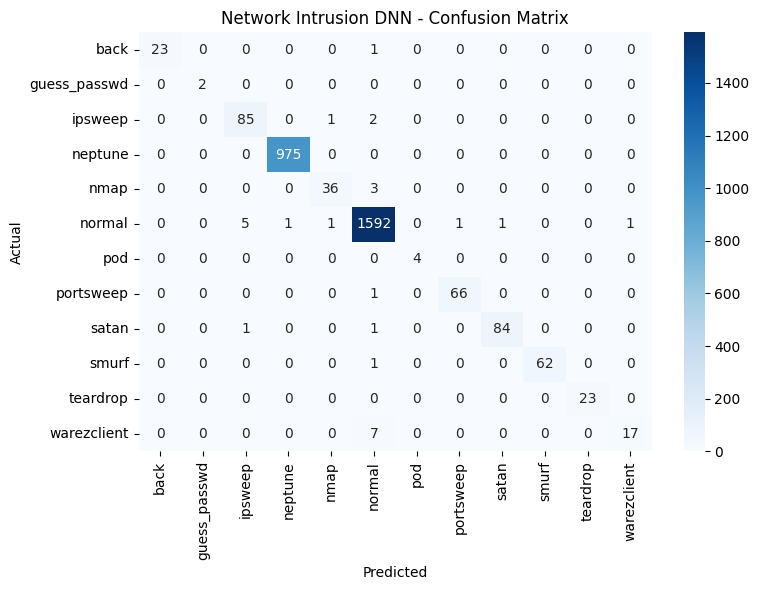

In [ ]:
# Cell 5 - Train and evaluate the Network Intrusion Detection DNN

X_network, y_network, network_encoder = prepare_dataset(network_df, "label")

(
    X_train_network,
    X_test_network,
    y_train_network,
    y_test_network,
    network_scaler,
    network_model
) = split_scale_train(X_network, y_network)

results["Network DNN"] = evaluate(
    network_model,
    X_test_network,
    y_test_network,
    network_encoder,
    "Network Intrusion DNN",
    "network_dnn_confusion_matrix.png"
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os

save_dir = "/content/drive/MyDrive/CyberThreatDetectionSamples"
os.makedirs(save_dir, exist_ok=True)

# Convert numpy array back to DataFrame
sample_network = pd.DataFrame(
    X_test_network,
    columns=X_network.columns
)

# Randomly pick 20 rows
sample_network = sample_network.sample(
    n=min(20, len(sample_network)),
    random_state=42
)

sample_network.to_csv(
    f"{save_dir}/sample_network.csv",
    index=False
)

print("✅ Saved successfully!")
print(sample_network.head())
print("Location:", f"{save_dir}/sample_network.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved successfully!
      duration  protocol_type   service      flag  src_bytes  dst_bytes  \
1375 -0.111122      -2.224015  3.565763 -0.616496  -0.022599  -0.038250   
932  -0.111122      -2.224015 -0.693440 -0.616496  -0.022605  -0.038322   
144  -0.111122       0.115123 -0.461120  0.381553  -0.022654  -0.038938   
2937 -0.111122       0.115123 -0.616000 -0.616496  -0.022271  -0.032434   
51   -0.111122       0.115123  1.474882  1.379602  -0.022654  -0.038938   

          land  wrong_fragment  urgent       hot  ...  dst_host_count  \
1375 -0.009134       -0.091796     0.0 -0.095666  ...        0.734099   
932  -0.009134       -0.091796     0.0 -0.095666  ...        0.734099   
144  -0.009134       -0.091796     0.0 -0.095666  ...        0.734099   
2937 -0.009134       -0.091796     0.0 -0.095666  ...        0.734099   
51   -0.009134       -0.091796   

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os

save_dir = "/content/drive/MyDrive/CyberThreatDetectionSamples"
os.makedirs(save_dir, exist_ok=True)

# Convert numpy array back to DataFrame
sample_malware = pd.DataFrame(
    X_test_malware,
    columns=X_malware.columns
)

# Randomly select 20 rows
sample_malware = sample_malware.sample(
    n=min(20, len(sample_malware)),
    random_state=42
)

sample_malware.to_csv(
    f"{save_dir}/sample_malware.csv",
    index=False
)

print("✅ Saved successfully!")
print(sample_malware.head())
print("Location:", f"{save_dir}/sample_malware.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved successfully!
     feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
696   0.091007   1.021441  -0.063833  -0.348412   0.066046  -0.592628   
667  -1.921090  -0.842356   1.506285   0.876705   0.266044   0.208566   
63    0.383220   0.446333   0.048927  -0.005718  -1.978145  -0.871013   
533  -0.897962  -0.720326   1.128541  -2.136104  -0.713652  -0.255376   
66   -0.644710   1.710324  -1.080912   0.597156  -0.650596  -0.439403   

     feature_6  feature_7  feature_8  feature_9  ...  feature_20  feature_21  \
696   0.999633  -0.774225   0.706648   0.731592  ...    0.126664    1.225498   
667  -0.589520   0.172692   0.914298  -0.396275  ...    0.933884    0.784215   
63   -0.590152  -0.080173  -0.119436   1.759641  ...    0.993816    0.140107   
533   1.526247   0.574439  -0.395360   1.566162  ...   -0.003644    1.522480   
66   -0.96

Network RF Accuracy: 0.997
Network RF Weighted F1: 0.997


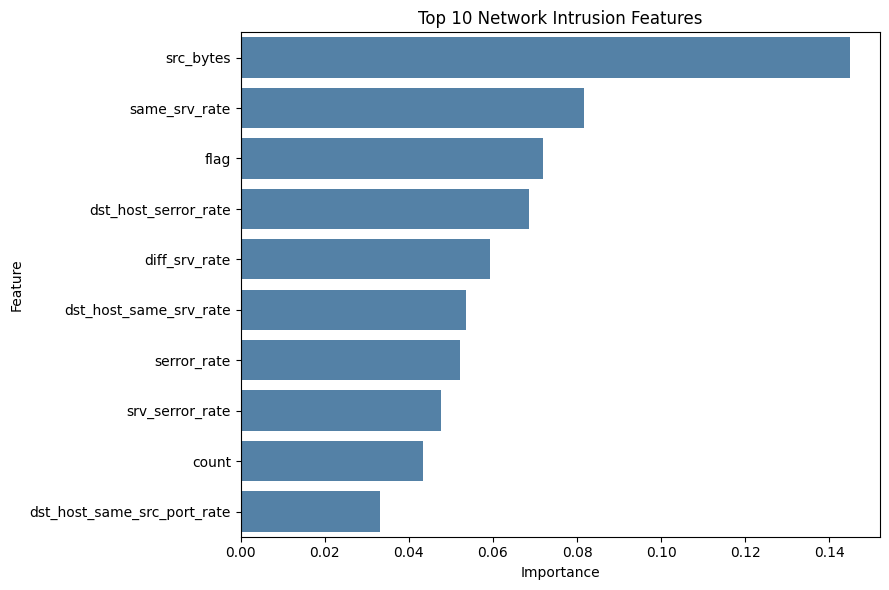

,Feature,Importance
4,src_bytes,0.144815
28,same_srv_rate,0.081705
3,flag,0.071847
37,dst_host_serror_rate,0.068507
29,diff_srv_rate,0.059244
33,dst_host_same_srv_rate,0.053586
24,serror_rate,0.052236
25,srv_serror_rate,0.047578
22,count,0.043328
35,dst_host_same_src_port_rate,0.033170


In [ ]:
# Cell 6 - Network Random Forest baseline and feature importance

network_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
network_rf.fit(X_train_network, y_train_network)

network_rf_pred = network_rf.predict(X_test_network)

results["Network Random Forest"] = {
    "accuracy": accuracy_score(y_test_network, network_rf_pred),
    "weighted_f1": f1_score(
        y_test_network,
        network_rf_pred,
        average="weighted",
        zero_division=0
    )
}

print("Network RF Accuracy:", round(results["Network Random Forest"]["accuracy"], 4))
print("Network RF Weighted F1:", round(results["Network Random Forest"]["weighted_f1"], 4))

network_feature_importance = plot_feature_importance(
    network_rf,
    X_network.columns,
    "Top 10 Network Intrusion Features",
    "network_feature_importance.png"
)

network_feature_importance

In [ ]:
# Cell 7 - Load malware data
malware_url = 'https://raw.githubusercontent.com/urwithajit9/ClaMP/master/ClaMP_Integrated-5184.csv'
malware_df, malware_is_real = safe_load_csv(malware_url, fallback_shape=(4000, 30), fallback_classes=2)
if malware_is_real:
    candidates = ['class', 'Class', 'label', 'Label', 'malware']
    malware_label = next((c for c in candidates if c in malware_df.columns), malware_df.columns[-1])
else:
    malware_label = 'label'
print('Malware source:', 'ClaMP' if malware_is_real else 'synthetic fallback')
print('Label column:', malware_label)
malware_df.head()

Using synthetic fallback because loading failed: HTTPError
Malware source: synthetic fallback
Label column: label


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,label
0,-0.759840,-1.088635,2.098945,0.623083,1.741170,2.008147,-0.739028,-2.531035,2.371827,-0.306597,...,-1.598797,1.182698,-0.489658,-0.889279,-0.095241,-3.457079,4.732306,-1.251385,-1.324692,class_0
1,-0.793820,3.707129,-1.911966,0.377074,1.087173,-5.004365,1.365706,-4.250381,0.612717,-0.682509,...,0.379040,1.545494,-0.514239,0.332914,1.773275,2.251538,-0.393106,-0.484061,0.300410,class_0
2,-1.542472,2.487502,-1.163633,0.365485,0.935441,-1.142604,2.159641,3.361989,-0.425158,-1.650829,...,-0.345883,0.743997,3.942814,-0.771110,3.079229,-2.129105,-2.120844,0.461952,-0.004966,class_0
3,-0.369155,-0.613351,0.450163,-1.106009,-0.878351,2.182731,-0.210210,2.436141,-0.842684,0.200137,...,0.311239,-0.190330,-2.242930,0.280099,-4.371375,-2.842642,-3.808190,0.384665,0.340387,class_1
4,-1.111180,-1.108562,2.063182,-1.058248,-2.501108,4.187753,-0.952073,-0.220332,0.551687,1.481993,...,-1.724067,0.833693,1.333888,0.656118,1.206400,0.476459,3.477919,-1.191245,-0.599781,class_0



--- Malware DNN ---
Accuracy: 0.975
Weighted F1: 0.975
              precision    recall  f1-score   support

     class_0       0.97      0.97      0.97       399
     class_1       0.98      0.98      0.98       401

    accuracy                           0.97       800
   macro avg       0.97      0.97      0.97       800
weighted avg       0.97      0.97      0.97       800



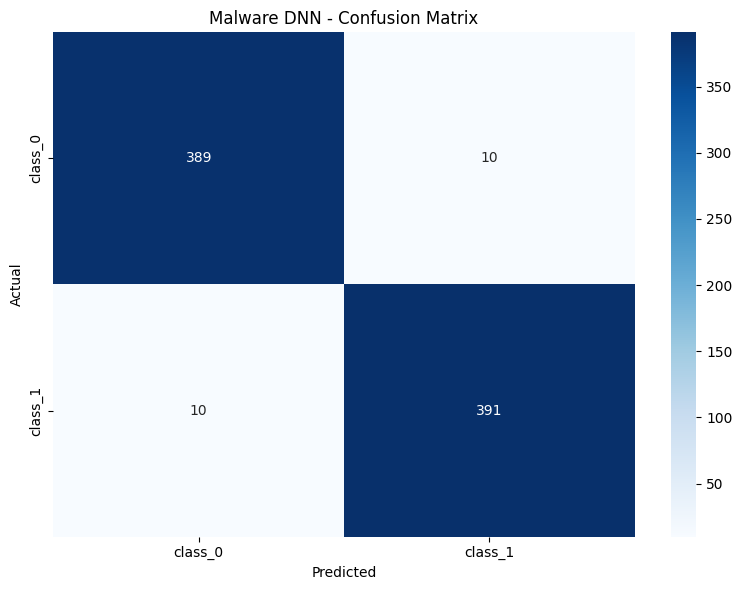

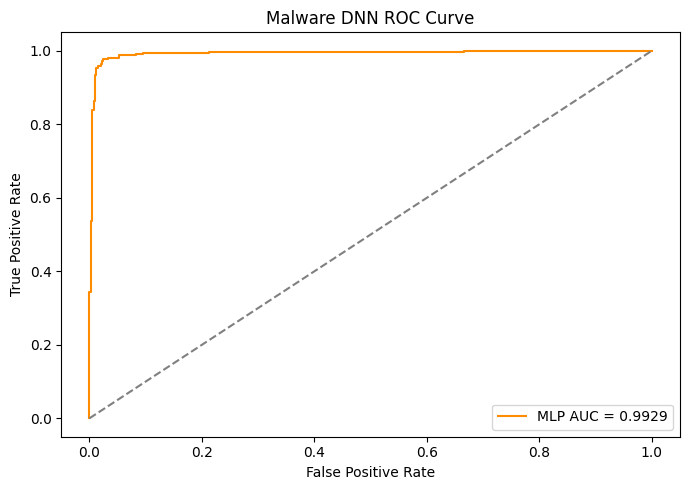

Malware DNN ROC-AUC: 0.9929


In [ ]:
# Cell 8 - Train and evaluate the Malware DNN

X_malware, y_malware, malware_encoder = prepare_dataset(malware_df, malware_label)

(
    X_train_malware,
    X_test_malware,
    y_train_malware,
    y_test_malware,
    malware_scaler,
    malware_model
) = split_scale_train(X_malware, y_malware)

results["Malware DNN"] = evaluate(
    malware_model,
    X_test_malware,
    y_test_malware,
    malware_encoder,
    "Malware DNN",
    "malware_dnn_confusion_matrix.png"
)

# ROC-AUC is meaningful only for a binary malware dataset.
if len(malware_encoder.classes_) == 2:
    malware_probabilities = malware_model.predict_proba(X_test_malware)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_malware, malware_probabilities)
    malware_auc = auc(fpr, tpr)

    results["Malware DNN"]["roc_auc"] = malware_auc

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"MLP AUC = {malware_auc:.4f}", color="darkorange")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Malware DNN ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig("malware_dnn_roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Malware DNN ROC-AUC:", round(malware_auc, 4))
else:
    print("ROC-AUC skipped because this malware dataset is not binary.")

In [ ]:
# Cell 9 - Malware Random Forest baseline

malware_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
malware_rf.fit(X_train_malware, y_train_malware)

malware_rf_pred = malware_rf.predict(X_test_malware)

results["Malware Random Forest"] = {
    "accuracy": accuracy_score(y_test_malware, malware_rf_pred),
    "weighted_f1": f1_score(
        y_test_malware,
        malware_rf_pred,
        average="weighted",
        zero_division=0
    )
}

print("Malware RF Accuracy:", round(results["Malware Random Forest"]["accuracy"], 4))
print("Malware RF Weighted F1:", round(results["Malware Random Forest"]["weighted_f1"], 4))

Malware RF Accuracy: 0.9613
Malware RF Weighted F1: 0.9612


In [ ]:
# Cell 10 - Unified detection, comparison table, and saved model artifacts

def detect_threat(threat_type, scaled_sample, model, encoder):
    predicted_index = model.predict(scaled_sample)[0]
    predicted_label = encoder.inverse_transform([predicted_index])[0]
    confidence = model.predict_proba(scaled_sample)[0, predicted_index]

    print(
        f"[{threat_type.upper()}] Prediction: {predicted_label} | "
        f"Confidence: {confidence:.2%}"
    )
    return predicted_label, confidence


print("Demo predictions:")
detect_threat("network", X_test_network[:1], network_model, network_encoder)
detect_threat("malware", X_test_malware[:1], malware_model, malware_encoder)

comparison_table = pd.DataFrame([
    {
        "Model": "MLP",
        "Dataset": "NSL-KDD Network Intrusion",
        "Accuracy": results["Network DNN"]["accuracy"],
        "Weighted F1": results["Network DNN"]["weighted_f1"]
    },
    {
        "Model": "Random Forest",
        "Dataset": "NSL-KDD Network Intrusion",
        "Accuracy": results["Network Random Forest"]["accuracy"],
        "Weighted F1": results["Network Random Forest"]["weighted_f1"]
    },
    {
        "Model": "MLP",
        "Dataset": "Malware Classification",
        "Accuracy": results["Malware DNN"]["accuracy"],
        "Weighted F1": results["Malware DNN"]["weighted_f1"]
    },
    {
        "Model": "Random Forest",
        "Dataset": "Malware Classification",
        "Accuracy": results["Malware Random Forest"]["accuracy"],
        "Weighted F1": results["Malware Random Forest"]["weighted_f1"]
    }
])

comparison_table.to_csv("model_comparison.csv", index=False)
display(comparison_table.round(4))

# Save all artifacts required by the Streamlit dashboard.
joblib.dump(network_model, "nids_model.pkl")
joblib.dump(malware_model, "malware_model.pkl")
joblib.dump(network_scaler, "nids_scaler.pkl")
joblib.dump(malware_scaler, "malware_scaler.pkl")
joblib.dump(network_encoder, "nids_label_encoder.pkl")
joblib.dump(malware_encoder, "malware_label_encoder.pkl")

print("\nSaved successfully:")
print("- nids_model.pkl")
print("- malware_model.pkl")
print("- nids_scaler.pkl")
print("- malware_scaler.pkl")
print("- nids_label_encoder.pkl")
print("- malware_label_encoder.pkl")
print("- model_comparison.csv")

Demo predictions:
[NETWORK] Prediction: smurf | Confidence: 100.00%
[MALWARE] Prediction: class_1 | Confidence: 100.00%


,Model,Dataset,Accuracy,Weighted F1
0,MLP,NSL-KDD Network Intrusion,0.9907,0.9905
1,Random Forest,NSL-KDD Network Intrusion,0.9970,0.9970
2,MLP,Malware Classification,0.9750,0.9750
3,Random Forest,Malware Classification,0.9612,0.9612



Saved successfully:
- nids_model.pkl
- malware_model.pkl
- nids_scaler.pkl
- malware_scaler.pkl
- nids_label_encoder.pkl
- malware_label_encoder.pkl
- model_comparison.csv
